In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

In [117]:
columns = ['date', 'name', 'fin_date', 'value', 'account', 'nan', 'code']  # replace with your actual column names

data1 = pd.read_csv(r'data/1.txt', sep='|', header=None, names=columns, encoding='latin1')
data2 = pd.read_csv(r'data/2.txt', sep='|', header=None, names=columns, encoding='latin1')
df = pd.concat([data1, data2])

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['consecutive'] = df['date'].dt.year + (df['date'].dt.month /12)

df = df.drop(['nan', 'fin_date', 'account'], axis=1) 

In [93]:
include = [
    "SUPER VINI",
    "ALCAMPO",
    "MARKET",
    "FRUTA",
    "mercadona",
    "carniceria",
    "veterinaria",
    "carref",
    "hiper",
    "papa jonhs",
    "polleria",
    "organic shop",
    "LIDL",
    "Simyo",
    "alejandro",
    "SANTIAGO",
    "Amon",
    "SEGUROS ADESLAS",
    "ELECTRICIDAD IBERDROLA",
    "AGUA CANAL",
    "LAS ROZAS",
    "ELECTRICIDAD FACTOR ENERGIA",
    "PESCADERIA",
    "dulce",
    "quesos",
    "paladar"
    ]
include = [s.lower().strip() for s in include]

exclude = [
    "IKEA",
    "EL CORTE INGLES",
    "LEROY MERLIN",
    "AUTOESCUELA",
    "XE EUROPE",
    "Decorabano-Armilla",
    "Arciniega",
    "TRASPASO",
    "IBERIA",
    ]
exclude = [s.lower().strip() for s in exclude]

def filter_rows(df):
    df = df[df['name'].str.contains('|'.join(include), case=False, na=False)]
    df = df[~df['name'].str.contains('|'.join(exclude), case=False, na=False)]
    return df

# Apply the function to the DataFrame
filtered_df = filter_rows(df)

,month,value
0,2021.666667,-65.71
1,2021.916667,-189.63
2,2022.000000,-227.71
3,2022.083333,-1729.32
4,2022.166667,-178.44
5,2022.250000,-324.33
6,2022.333333,-248.88
7,2022.416667,-266.83
8,2022.500000,-615.32
9,2022.583333,-470.00


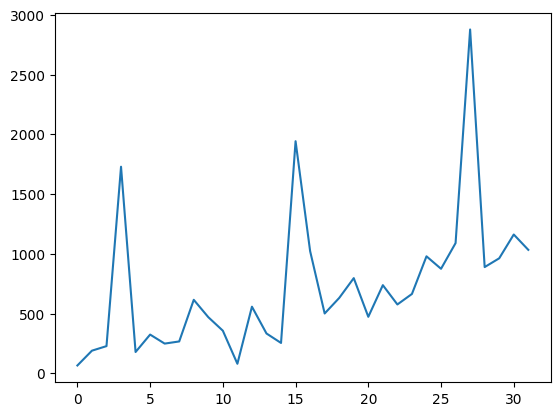

In [108]:
monthly = filtered_df.groupby('consecutive')['value'].sum().reset_index()

monthly.columns = ['month', 'value']
plt.plot(monthly.value*-1)
monthly

In [116]:
def filter_by_date(df, month, year):
    return df[(df['date'].dt.month == month) & (df['date'].dt.year == year)]

filter_by_date(filtered_df,2,2024).value.sum()

-889.3199999999999